In [2]:
import os

USER_PATH = '~/OneDrive - PNNL'
DATA_PATH = 'E-COMP - mocodo'

path = os.path.join(os.path.expanduser(USER_PATH), DATA_PATH)


os.listdir(path)

['scenarios_wrevenues.csv',
 'scenarios_wrevenues_subset.csv',
 'design_solutions.csv',
 'design_solutions_v0.csv',
 'scenarios.csv',
 'MoCoDo formulation.docx',
 'design_solutions_per_scenario.csv']

In [3]:
import pandas as pd

df_design = pd.read_csv(os.path.join(path, 'design_solutions_v0.csv'), index_col=0)

\begin{tabular}{llllllll}
\toprule
 & $r_1$ & $r_2$ & $r_3$ & $r_4$ & $r_5$ & $r_6$ & $g$ \\
$i$ &  &  &  &  &  &  &  \\
\midrule
1 & \hi{6} & \hi{4} & \hi{7} & \hi{2} & \hi{4} & \hi{7} &  \\
2 & \hi{4} & 5 & \hi{5} & 4 & 8 & \hi{5} &  \\
3 & \hi{1} & 8 & \hi{3} & 8 & 5 & \hi{3} &  \\
4 & 2 & \hi{3} & 8 & 7 & 7 & 8 &  \\
5 & 5 & 9 & \hi{2} & 3 & \hi{2} & \hi{2} &  \\
6 & 9 & 6 & 6 & \hi{1} & 3 & 6 &  \\
7 & \hi{8} & \hi{7} & \hi{4} & \hi{9} & \hi{6} & \hi{4} &  \\
8 & 7 & \hi{2} & 9 & 5 & 9 & 9 &  \\
9 & 10 & 10 & \hi{1} & 10 & \hi{1} & \hi{1} &  \\
10 & 3 & \hi{1} & 10 & 6 & 10 & 10 &  \\
\bottomrule
\end{tabular}



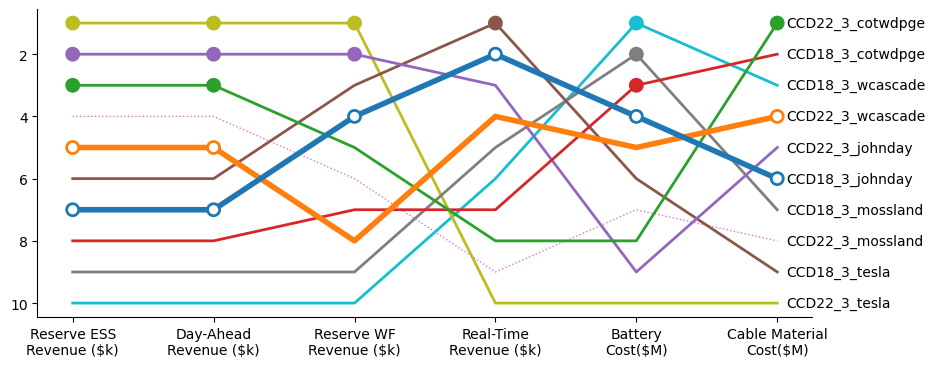

In [117]:
import numpy as np
import matplotlib.pyplot as plt

from importlib import reload
import tradeoff_lattice as tl; reload(tl)

ovars = [
    c
    for c in df_design.columns
    if '$' in c
]

def ovar_format(s):
    sep = ' Revenue'
    if ' Cost' in s:
        sep = ' Cost'

    left, right = s.split(sep)
    return f'{left}\n{sep[1:]}{right}'
    
ascending = [
    c
    for c in ovars
    if 'Cost' in c
]

dvars = set(df_design.columns).difference(ovars)

self = tl.TradeoffLattice(
    df_design, ovars, dvars,
    ascending=ascending
)

by = ovars[0]

plt.figure(figsize=(10, 4))
self.plot_pcp(
    x_label_format=ovar_format,
    # specialization=self.specialization_at_k(2),
    generalizers=self.rank.index[:2],
    # subset=self.specializers,
    # generalizers=self.specialization.index[:2],
)

print(self.to_latex(
    index=pd.Index(np.arange(len(self.rank)) + 1, name='$i$'),
    columns=[f'$r_{i + 1}$' for i in range(len(self.rank.columns))]
))

In [121]:
self.specialization_at_k(3)

,Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
CCD18_3_johnday,True,True,True,True,True,True
CCD22_3_wcascade,True,True,True,True,True,True
CCD22_3_cotwdpge,True,True,True,True,True,True
CCD18_3_cotwdpge,False,True,False,False,False,False
CCD22_3_johnday,False,False,True,False,True,True
CCD18_3_tesla,False,False,False,True,True,False
CCD18_3_mossland,False,True,False,False,False,False
CCD22_3_tesla,False,False,True,False,True,True
CCD18_3_wcascade,False,True,False,False,False,False


In [110]:
self.specialization_at_k(1,)

,Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
CCD22_3_wcascade,True,False,True,False,False,True
CCD22_3_cotwdpge,True,False,True,False,False,True
CCD18_3_cotwdpge,True,True,False,False,False,False
CCD22_3_johnday,True,False,True,False,True,True
CCD18_3_tesla,False,False,True,True,True,True
CCD22_3_mossland,False,False,True,False,False,True
CCD18_3_mossland,False,True,False,False,False,False
CCD22_3_tesla,False,False,True,False,True,True
CCD18_3_wcascade,True,True,False,False,False,False


In [86]:
self.specializer_cover()

Index(['CCD22_3_wcascade', 'CCD18_3_cotwdpge', 'CCD22_3_johnday',
       'CCD18_3_tesla'],
      dtype='object')

In [88]:
self.specialization.loc[self.specializer_cover()]

,Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve WF Revenue ($k),Reserve ESS Revenue ($k)
CCD22_3_wcascade,True,False,True,False,False,True
CCD18_3_cotwdpge,False,True,False,False,False,False
CCD22_3_johnday,False,False,True,False,True,True
CCD18_3_tesla,False,False,False,True,False,False


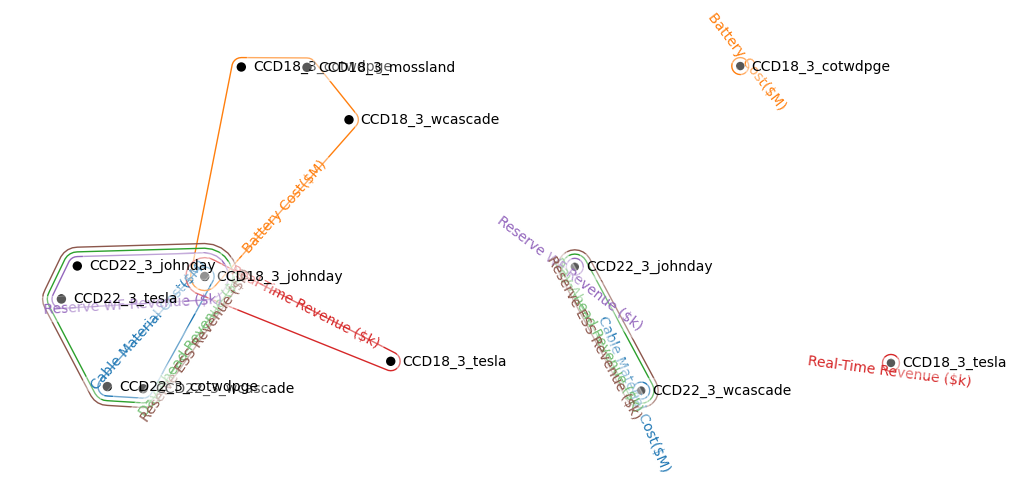

In [91]:
import hypernetx as hnx

plt.figure(figsize=(12, 5))

plt.subplot(121)
H = self.specializers_as_hypergraph(subset=self.specialization.index)
pos = hnx.draw(H, return_pos=True)

plt.subplot(122)
H = self.specializers_as_hypergraph(subset=self.specializer_cover())
hnx.draw(H, pos=pos)